In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix


from xgboost import XGBClassifier

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

import seaborn as sns

In [91]:
dataset = pd.read_csv(r'..\data\raw\retail_sku_dataset_sintetico_10000_filas_70_variables.csv')

In [92]:
#Brief preliminar overview
resumen_calidad = pd.DataFrame({
    'tipo': dataset.dtypes.astype(str),
    'nulos': dataset.isna().sum(),
    'nulos_pct': (dataset.isna().mean() * 100).round(2),
    'valores_unicos': dataset.nunique(dropna=True)
}).sort_values('nulos_pct', ascending=False)

resumen_calidad.head(20)

,tipo,nulos,nulos_pct,valores_unicos
stock_actual,float64,114,1.14,134
margen_pct,float64,99,0.99,38
forecast_30d,float64,91,0.91,238
precio_venta,object,85,0.85,3733
fill_rate_pct,object,72,0.72,315
proveedor,object,61,0.61,5
rating_cliente,float64,61,0.61,31
categoria,object,46,0.46,14
distrito,object,0,0.00,10
ciudad,object,0,0.00,12


In [93]:
dataset

,sku_id,tienda_id,fecha,region,ciudad,distrito,formato_tienda,canal_venta,cluster_tienda,segmento_cliente_principal,categoria,subcategoria,marca,proveedor,sku_estado,precio_lista,precio_venta,costo_unitario,margen_pct,descuento_pct,stock_actual,stock_seguridad,inventario_transito,dias_inventario,ventas_unidades_7d,ventas_unidades_30d,ventas_valor_30d,unidades_devueltas_30d,rotacion_30d,forecast_7d,forecast_30d,error_forecast_pct,quiebres_7d,quiebres_30d,visitas_tienda_30d,tickets_30d,tasa_conversion_pct,share_categoria_pct,competencia_precio_prom,precio_vs_competencia_pct,elasticidad_precio,promo_activa,tipo_promo,dias_promo_mes,inversion_trade,exhibicion_secundaria,espacio_gondola_cm,puntaje_planograma,cumplimiento_sla_pct,fill_rate_pct,lead_time_dias,frecuencia_reposicion_dias,temperatura_promedio,lluvia_mm_mes,feriado_mes,evento_local,campania_marketing,canal_abastecimiento,nivel_socioeconomico_zona,distancia_cd_km,capacidad_bodega_m3,merma_pct,vencimiento_dias,vida_util_dias,reclamos_30d,rating_cliente,score_tendencia_categoria,prioridad_comercial,riesgo_quiebre_score,target_reponer_sku
0,SKU-0655,TDA-029,2025-02-17,Lima,Callao,SJL,Supermercado,Tradicional,Bajo valor,Mascotas,Lacteos,Yogurt,Marca_E,Proveedor_Local,Activo,6.72,6.72,5.85,0.13,0.0,31.0,24,14,10.4,23,89,598.08,1,2.87,21,82.0,0.08,0,1,1962,917,0.467,0.141,5.94,0.131,-2.29,0,Sin promo,0,0.00,0,116.6,0.89,0.917,0.856,7,3,24.1,182.5,0,Campana escolar,Trade marketing,CD Regional,D,40.9,33.5,0.023,39,45,2,3.7,0.484,Alta,31.3,0
1,SKU-0272,TDA-036,2025-01-25,Lima,Callao,Industrial,Bodega,Tradicional,Alto valor,Ahorro,Snacks,Galletas,Marca_E,Proveedor_Local,Activo,10.54,9.49,6.07,0.36,0.1,0.0,18,2,0.0,19,74,702.26,2,74.00,19,75.0,0.01,1,5,1633,461,0.282,0.126,9.58,-0.009,-2.49,1,Combo,19,3833.61,0,37.0,0.79,0.947,0.847,4,4,20.2,35.5,0,Fiesta local,Ninguna,Proveedor directo,C,96.9,48.7,0.079,31,120,0,3.2,0.217,Alta,93.7,1
2,SKU-0033,TDA-221,2025-08-31,Lima,Lima,Surco,Minimarket,Moderno,Medio valor,Familias,Bebidas,Jugos,Marca_E,Proveedor_Local,Activo,6.84,6.29,4.53,0.28,0.08,27.0,14,0,15.9,14,51,320.79,1,1.89,18,60.0,0.18,0,4,3147,990,0.315,0.172,6.52,-0.035,-1.95,1,2x1,17,4059.31,0,35.7,0.80,0.866,0.704,2,14,30.7,36.6,0,Ninguno,Influencers,CD Central,B,3.8,51.7,0.074,210,730,1,4.0,0.312,Media,42.8,0
3,SKU-0245,TDA-068,2025-02-07,Lima,Callao,La Molina,Supermercado,Tradicional,Alto valor,Familias,Bebidas,Isotonicas,Marca_E,Proveedor_Norte,Temporal,5.23,5.23,4.34,0.17,0.0,8.0,13,5,3.0,19,81,423.63,3,10.12,15,68.0,0.16,1,5,4598,1241,0.270,0.259,6.26,-0.165,-2.20,0,Sin promo,0,0.00,1,37.1,0.75,0.794,0.875,12,7,16.5,139.5,0,Ninguno,Ninguna,CD Central,C,705.3,12.9,0.027,39,60,0,4.1,0.391,Media,74.5,1
4,SKU-0423,TDA-007,2025-01-20,Lima,Callao,Comas,Minimarket,Mayorista,Descuento,Jovenes,Limpieza,Desinfectante,Marca_B,Proveedor_Andes,Activo,39.49,28.04,19.91,0.29,0.29,28.0,4,9,27.1,7,31,869.24,1,1.11,5,25.0,0.19,1,5,1666,465,0.279,0.030,46.38,-0.395,-1.93,1,Cupon,11,287.46,0,75.3,0.87,0.838,0.985,2,8,31.8,41.8,1,Ninguno,Trade marketing,CD Regional,C,61.3,82.4,0.026,120,180,0,4.6,0.317,Media,41.2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,SKU-0142,TDA-077,2025-08-06,Centro,Ica,Industrial,Cash&Carry,Tradicional,Conveniencia,Oficinas,Snacks,Galletas,Marca_C,Proveedor_Andes,Activo,2.1,1.87,1.55,0.17,0.11,50.0,37,8,14.3,22,105,196.35,1,2.10,31,130.0,0.24,0,2,3967,1337,0.337,0.148,2.50,-0.252,-2.35,1,2x1,5,1786.72,0,153.4,0.86,0.781,0.954,3,8,13.6,22.8,0,Ninguno,Digital,CD Central,E,140.0,26.4,0.011,21,45,1,4.8,0.359,Media,43.7,0
9996,SKU-0081,TDA-043,2025-09-10,Norte,Chiclayo,Comas,Bodega,Moderno,Bajo valor,Premium,Limpieza,Desinfectante,Marca_A,Proveedor_Global,Activo,27.46,27.46,19.22,0.30,0.0,19.0,13,11,10.6,12,54,1482.84,2,2.84,16,60.0

In [94]:
print("Number of items:", len(dataset.sku_id.unique()))

print("Number of stores:", len(dataset.tienda_id.unique()))

Number of items: 900
Number of stores: 250


In [95]:
dataset.columns

Index(['sku_id', 'tienda_id', 'fecha', 'region', 'ciudad', 'distrito', 'formato_tienda', 'canal_venta', 'cluster_tienda', 'segmento_cliente_principal',
       'categoria', 'subcategoria', 'marca', 'proveedor', 'sku_estado', 'precio_lista', 'precio_venta', 'costo_unitario', 'margen_pct', 'descuento_pct',
       'stock_actual', 'stock_seguridad', 'inventario_transito', 'dias_inventario', 'ventas_unidades_7d', 'ventas_unidades_30d', 'ventas_valor_30d',
       'unidades_devueltas_30d', 'rotacion_30d', 'forecast_7d', 'forecast_30d', 'error_forecast_pct', 'quiebres_7d', 'quiebres_30d', 'visitas_tienda_30d',
       'tickets_30d', 'tasa_conversion_pct', 'share_categoria_pct', 'competencia_precio_prom', 'precio_vs_competencia_pct', 'elasticidad_precio',
       'promo_activa', 'tipo_promo', 'dias_promo_mes', 'inversion_trade', 'exhibicion_secundaria', 'espacio_gondola_cm', 'puntaje_planograma',
       'cumplimiento_sla_pct', 'fill_rate_pct', 'lead_time_dias', 'frecuencia_reposicion_dias', 'tempe

In [96]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 70 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   sku_id                      10000 non-null  object 
 1   tienda_id                   10000 non-null  object 
 2   fecha                       10000 non-null  object 
 3   region                      10000 non-null  object 
 4   ciudad                      10000 non-null  object 
 5   distrito                    10000 non-null  object 
 6   formato_tienda              10000 non-null  object 
 7   canal_venta                 10000 non-null  object 
 8   cluster_tienda              10000 non-null  object 
 9   segmento_cliente_principal  10000 non-null  object 
 10  categoria                   9954 non-null   object 
 11  subcategoria                10000 non-null  object 
 12  marca                       10000 non-null  object 
 13  proveedor                   9939

In [97]:
dataset.iloc[:, :-40].describe()

# there is negative stock ?

,costo_unitario,margen_pct,stock_actual,stock_seguridad,inventario_transito,dias_inventario,ventas_unidades_7d,ventas_unidades_30d,ventas_valor_30d,unidades_devueltas_30d,rotacion_30d,forecast_7d
count,10000.000000,9901.000000,9886.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,10.945742,0.306052,24.350900,18.62000,9.46260,10.128820,17.692200,700.32930,925.230898,1.379100,7.384792,18.992900
std,10.603097,0.124446,18.691965,11.11918,8.05175,6.820737,9.967557,7907.01668,885.929000,1.253611,13.558708,10.956809
min,0.540000,0.120000,-25.000000,3.00000,0.00000,0.000000,0.000000,1.00000,2.050000,0.000000,0.020000,0.000000
25%,3.750000,0.210000,10.000000,11.00000,2.00000,5.200000,10.000000,43.00000,338.985000,0.000000,2.000000,11.000000
50%,6.910000,0.300000,22.000000,17.00000,9.00000,9.700000,16.000000,68.00000,642.720000,1.000000,2.950000,17.000000
75%,14.925000,0.390000,36.000000,25.00000,15.00000,14.200000,24.000000,95.00000,1177.852500,2.000000,5.200000,25.000000
max,77.250000,1.250000,127.000000,92.00000,44.00000,53.000000,65.000000,99999.00000,6378.400000,7.000000,133.000000,82.000000


In [98]:
# Examine the target variable

dataset['target_reponer_sku'].value_counts(normalize=True)

# target_reponer_sku

target_reponer_sku
0    0.606
1    0.394
Name: proportion, dtype: float64

In [99]:
# Exploring ID group variables: sku_id, tienda_id, fecha 

dataset[dataset[['sku_id', 'tienda_id', 'fecha']].duplicated(keep='last') ].sort_values(by=['sku_id', 'tienda_id', 'fecha'])

,sku_id,tienda_id,fecha,region,ciudad,distrito,formato_tienda,canal_venta,cluster_tienda,segmento_cliente_principal,categoria,subcategoria,marca,proveedor,sku_estado,precio_lista,precio_venta,costo_unitario,margen_pct,descuento_pct,stock_actual,stock_seguridad,inventario_transito,dias_inventario,ventas_unidades_7d,ventas_unidades_30d,ventas_valor_30d,unidades_devueltas_30d,rotacion_30d,forecast_7d,forecast_30d,error_forecast_pct,quiebres_7d,quiebres_30d,visitas_tienda_30d,tickets_30d,tasa_conversion_pct,share_categoria_pct,competencia_precio_prom,precio_vs_competencia_pct,elasticidad_precio,promo_activa,tipo_promo,dias_promo_mes,inversion_trade,exhibicion_secundaria,espacio_gondola_cm,puntaje_planograma,cumplimiento_sla_pct,fill_rate_pct,lead_time_dias,frecuencia_reposicion_dias,temperatura_promedio,lluvia_mm_mes,feriado_mes,evento_local,campania_marketing,canal_abastecimiento,nivel_socioeconomico_zona,distancia_cd_km,capacidad_bodega_m3,merma_pct,vencimiento_dias,vida_util_dias,reclamos_30d,rating_cliente,score_tendencia_categoria,prioridad_comercial,riesgo_quiebre_score,target_reponer_sku
4237,SKU-0326,TDA-066,2025-09-27,Sur,Arequipa,SJL,Bodega,Moderno,Medio valor,Oficinas,Limpieza,Papel,Marca_Propia,Proveedor_Global,Activo,23.71,23.71,20.63,0.13,0.0,33.0,22,12,16.5,12,60,1422.60,2,1.82,18,64.0,0.07,1,5,3201,1461,0.456,0.085,26.07,-0.091,-1.85,0,Sin promo,0,0.00,0,163.2,0.86,0.986,0.878,2,2,32.9,154.1,1,Ninguno,Influencers,CD Regional,C,764.8,42.5,0.046,44,45,1,4.5,-0.204,Alta,38.3,0
6231,SKU-0368,TDA-128,2025-01-25,Norte,Trujillo,Ate,Ecommerce,Online,Conveniencia,Mascotas,Limpieza,Lavavajilla,Marca_Propia,Proveedor_Pacifico,Activo,21.49,21.49,16.55,0.23,0.0,2.0,10,3,2.0,6,22,472.78,1,11.00,8,NaN,0.23,1,3,2113,536,0.254,0.344,19.36,0.110,-0.81,0,Sin promo,0,0.00,0,125.2,0.74,0.825,0.721,9,6,22.1,151.0,0,Campana escolar,Ninguna,Cross docking,B,647.7,102.4,0.009,50,60,2,4.4,-0.026,Alta,77.0,1
9222,SKU-0508,TDA-219,2025-05-12,Lima,Callao,Ate,Hipermercado,Moderno,Descuento,Familias,Mascotas,Alimento gato,Marca_B,Proveedor_Global,Activo,24.4,24.4,15.37,0.37,0.0,21.0,4,0,21.0,5,18,439.20,1,0.86,4,20.0,0.11,0,4,4670,1822,0.390,0.035,29.61,-0.176,-0.63,0,Sin promo,0,0.00,0,38.8,0.68,0.778,0.987,12,12,25.0,2.5,1,Ninguno,Influencers,Proveedor directo,C,800.1,21.1,0.080,74,180,4,3.9,0.414,Media,24.9,0
2243,SKU-0517,TDA-155,2025-08-20,Norte,Trujillo,SJL,Bodega,Moderno,Descuento,Jovenes,Bebidas,Isotonicas,Marca_C,Proveedor_Norte,Activo,4.94,4.94,3.51,0.29,0.0,0.0,11,12,0.0,13,42,207.48,0,42.00,13,55.0,0.31,2,5,2004,399,0.199,0.123,5.94,-0.168,-1.56,0,Sin promo,0,0.00,1,137.7,0.67,0.812,0.733,10,8,24.8,37.0,0,Partido,TV,CD Central,D,260.9,84.0,0.031,68,180,2,3.5,-0.183,Baja,80.9,1
5101,SKU-0595,TDA-035,2025-04-05,Lima,Callao,Ate,Hipermercado,Moderno,Descuento,Ahorro,Mascotas,Alimento gato,Marca_C,Proveedor_Pacifico,Activo,32.72,25.85,21.20,0.18,0.21,40.0,26,20,13.2,26,91,2352.35,3,2.27,23,76.0,0.16,0,2,2147,870,0.405,0.061,38.16,-0.323,-0.31,1,Cupon,19,4454.07,0,138.2,0.89,0.752,0.771,4,7,30.6,169.9,0,Ninguno,TV,Cross docking,D,504.7,8.5,0.027,27,45,0,3.5,0.348,Media,42.4,0
1246,SKU-0694,TDA-040,2025-06-26,Oriente,Pucallpa,Centro,Bodega,Moderno,Bajo valor,Premium,Bebidas,Agua,Marca Propia,Proveedor_Local,Nuevo,2.47,2.47,2.05,0.17,0.0,35.0,20,28,14.4,23,73,180.31,1,2.09,21,72.0,0.01,0,0,1976,515,0.261,0.280,2.41,0.025,-0.61,0,Sin promo,0,0.00,0,108.3,0.79,0.854,0.785,5,2,16.8,144.7,0,Temporada verano,CRM,CD Regional,C,787.2,32.3,0.036,177,180,1,4.0,0.293,Media,33.1,0
5234,SKU-0737,TDA-073,2025-10-08,Lima,Lima,Comas,Minimarket,Online,Medio valor,Mascotas,Abarrotes,Arroz,Marca_Propia,Proveedor_Andes,Activo,19.61,17.45,9.60,0.45,11%,20.0,11,14,8.8,17,68,1186.60,2,3.40,14,58.0,0.15,0,2,2699,672,0.249,0.348,23.40,-0.254,-1.22,1,Combo,11,2967.05,0,124.0,0.76,0.932,0.88,8,8,27.0,169.3,0,Ninguno,Trade marketing,Cross docking,C,729.0,25.7,0.046,15,45,2,4.4,-0.090,Baja,25.8,0
3240,SKU-0758,TDA-024,2025-02-09,lima,Callao,Surco,Supermercado,Mayorista,

In [100]:
# Drop duplicated rows 

dataset_nodup = dataset.drop_duplicates(subset=['sku_id', 'tienda_id', 'fecha'], 
                                        keep='last').copy()



In [101]:
# Producto y tienda: categoria, marca, formato_tienda, canal_venta, cluster_tienda 

dataset_nodup[['categoria', 'marca', 'formato_tienda', 'canal_venta', 'cluster_tienda']].describe()

,categoria,marca,formato_tienda,canal_venta,cluster_tienda
count,9943,9989,9989,9989,9989
unique,14,14,12,4,5
top,Bebidas,Marca_E,Bodega,Moderno,Descuento
freq,2220,1454,2670,3879,2047


In [102]:
categoric_var = [ 'formato_tienda', 'canal_venta', 'cluster_tienda']

for col in categoric_var:
    
    print("#-------------------------------#")
    
    print(col)
    
    print(dataset_nodup[[col]].value_counts())
    

#-------------------------------#
formato_tienda
formato_tienda
Bodega            2670
Supermercado      2417
Minimarket        1561
Hipermercado      1418
Cash&Carry         983
Ecommerce          768
bodega              51
supermercado        44
minimarket          33
hipermercado        20
ecommerce           13
cash&carry          11
Name: count, dtype: int64
#-------------------------------#
canal_venta
canal_venta
Moderno        3879
Tradicional    3092
Online         1530
Mayorista      1488
Name: count, dtype: int64
#-------------------------------#
cluster_tienda
cluster_tienda
Descuento         2047
Conveniencia      2023
Medio valor       1983
Bajo valor        1970
Alto valor        1966
Name: count, dtype: int64


In [103]:
# Precio y margen:  precio_venta, descuento_pct, margen_pct, elasticidad_precio

dataset_nodup[['precio_venta', 'descuento_pct', 'margen_pct', 'elasticidad_precio']].describe()

# Numerical varaibles only margen_pct and elasticidad_precio.
# margen_pct has invalid values 

,margen_pct,elasticidad_precio
count,9890.000000,9989.00000
mean,0.306078,-1.40484
std,0.124474,0.63653
min,0.120000,-2.50000
25%,0.210000,-1.95000
50%,0.300000,-1.41000
75%,0.390000,-0.85000
max,1.250000,-0.30000


In [104]:
dataset_nodup[['precio_venta', 'descuento_pct']]

# String type of numerical variables 

,precio_venta,descuento_pct
0,6.72,0.0
1,9.49,0.1
2,6.29,0.08
3,5.23,0.0
4,28.04,0.29
...,...,...
9995,1.87,0.11
9996,27.46,0.0
9997,7.46,0.0
9998,14.99,0.0


In [105]:
# Inventario y venta 

dataset_nodup[['stock_actual', 'stock_seguridad', 'ventas_unidades_30d', 'rotacion_30d']].describe()

# Stock has incorrectly negative values 
# Ventas unidades a 30 días might have an outlier 

,stock_actual,stock_seguridad,ventas_unidades_30d,rotacion_30d
count,9875.000000,9989.000000,9989.000000,9989.000000
mean,24.358177,18.623186,701.033237,7.378501
std,18.694895,11.122816,7911.341035,13.553664
min,-25.000000,3.000000,1.000000,0.020000
25%,10.000000,11.000000,43.000000,2.000000
50%,22.000000,17.000000,68.000000,2.950000
75%,36.000000,25.000000,95.000000,5.200000
max,127.000000,92.000000,99999.000000,133.000000


In [106]:
# Forecast y quiebres 

dataset_nodup[['forecast_7d', 'forecast_30d', 'error_forecast_pct', 'quiebres_30d']].describe()

# why does erro forcast have only positive values 

,forecast_7d,forecast_30d,error_forecast_pct,quiebres_30d
count,9989.000000,9899.000000,9989.000000,9989.000000
mean,18.996196,75.898980,0.144832,2.672540
std,10.959860,42.401466,0.097448,1.690508
min,0.000000,1.000000,0.000000,0.000000
25%,11.000000,45.000000,0.060000,1.000000
50%,17.000000,70.000000,0.130000,3.000000
75%,25.000000,101.000000,0.210000,4.000000
max,82.000000,276.000000,0.500000,8.000000


In [107]:
# Promocion y trade 

dataset_nodup[['promo_activa', 'tipo_promo', 'inversion_trade', 'exhibicion_secundaria']].describe()

,inversion_trade
count,9989.000000
mean,785.425196
std,1399.498838
min,0.000000
25%,0.000000
50%,0.000000
75%,1090.880000
max,4999.180000


In [108]:
dataset_nodup[['promo_activa', 'tipo_promo', 'exhibicion_secundaria']]

# string type of numerical variables (promo_activa, exhibicion_secundaria)

,promo_activa,tipo_promo,exhibicion_secundaria
0,0,Sin promo,0
1,1,Combo,0
2,1,2x1,0
3,0,Sin promo,1
4,1,Cupon,0
...,...,...,...
9995,1,2x1,0
9996,0,Sin promo,0
9997,0,Sin promo,0
9998,0,Sin promo,1


In [109]:
dataset_nodup['tipo_promo'].value_counts() # eventual one-hot encoding 

tipo_promo
Sin promo    6844
Cabecera      642
Combo         641
2x1           624
Cupon         619
Descuento     619
Name: count, dtype: int64

In [110]:
# Operacion 

dataset_nodup[['fill_rate_pct', 'lead_time_dias', 'frecuencia_reposicion_dias']].describe() 

# negative values of lead_time_dias ??


,lead_time_dias,frecuencia_reposicion_dias
count,9989.000000,9989.000000
mean,6.438582,7.944839
std,3.512914,3.759977
min,-3.000000,2.000000
25%,3.000000,5.000000
50%,6.000000,8.000000
75%,10.000000,11.000000
max,12.000000,14.000000


In [111]:
dataset_nodup[['fill_rate_pct']]

# string type of numerical variable

,fill_rate_pct
0,0.856
1,0.847
2,0.704
3,0.875
4,0.985
...,...
9995,0.954
9996,0.974
9997,0.803
9998,0.946


In [112]:
# Contexto externo 

dataset_nodup[['feriado_mes', 'evento_local', 'temperatura_promedio', 'lluvia_mm_mes']].describe() 

,feriado_mes,temperatura_promedio,lluvia_mm_mes
count,9989.000000,9989.000000,9989.000000
mean,0.078086,22.957273,109.293893
std,0.268320,6.392710,63.568926
min,0.000000,12.000000,0.000000
25%,0.000000,17.400000,54.500000
50%,0.000000,22.900000,109.600000
75%,0.000000,28.500000,164.400000
max,1.000000,34.000000,220.000000


In [113]:
dataset_nodup[['evento_local']].value_counts() # eventual one-hot encoding 

evento_local    
Ninguno             7235
Partido              651
Temporada verano     613
Campana escolar      507
Fiesta local         492
Concierto            491
Name: count, dtype: int64

In [114]:
dataset_nodup[['exhibicion_secundaria', 'rating_cliente']].describe()

,rating_cliente
count,9928.000000
mean,4.090814
std,0.524838
min,1.800000
25%,3.700000
50%,4.100000
75%,4.500000
max,5.000000


In [115]:
dataset_nodup[['exhibicion_secundaria']] # string numerical variable

,exhibicion_secundaria
0,0
1,0
2,0
3,1
4,0
...,...
9995,0
9996,0
9997,0
9998,1


In [116]:
dataset_nodup[['riesgo_quiebre_score','dias_inventario']] .describe()

,riesgo_quiebre_score,dias_inventario
count,9989.000000,9989.000000
mean,44.837742,10.129973
std,21.876009,6.819538
min,0.000000,0.000000
25%,27.500000,5.200000
50%,38.400000,9.700000
75%,65.100000,14.200000
max,100.000000,53.000000


### II. ETL process & Feature Engeneering

In [117]:
import re

In [118]:
dataset_nodup[['precio_venta']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 9989 entries, 0 to 9999
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   precio_venta  9904 non-null   object
dtypes: object(1)
memory usage: 156.1+ KB


In [119]:
# Function to clear numerical variables 

def clean_prices(x)-> float:
   
    if pd.isna(x):
       return np.nan 
    
    output = re.sub(r"[^\d+\.]", "", x).strip()

    if not output:
        return np.nan
    
    return float(output)

In [120]:
# Precio y margen:  precio_venta, descuento_pct, margen_pct, elasticidad_precio

dataset_nodup[['precio_venta', 'descuento_pct', 'margen_pct', 'elasticidad_precio']].describe()

# Numerical varaibles only margen_pct and elasticidad_precio.
# margen_pct has invalid values 

dataset_nodup['precio_venta'] = dataset_nodup['precio_venta'].map(clean_prices)
dataset_nodup['descuento_pct'] = dataset_nodup['descuento_pct'].map(clean_prices)

In [121]:
dataset_nodup[['descuento_pct','precio_venta']].describe()

,descuento_pct,precio_venta
count,9989.000000,9904.000000
mean,0.113454,15.662456
std,1.076252,14.875764
min,0.000000,1.000000
25%,0.000000,5.460000
50%,0.000000,9.950000
75%,0.110000,21.275000
max,35.000000,89.830000


In [122]:
# Inventario y venta 

dataset_nodup[['stock_actual', 'stock_seguridad', 'ventas_unidades_30d', 'rotacion_30d']].describe()

# Stock has incorrectly negative values 
# Ventas unidades a 30 días might have an outlier 

,stock_actual,stock_seguridad,ventas_unidades_30d,rotacion_30d
count,9875.000000,9989.000000,9989.000000,9989.000000
mean,24.358177,18.623186,701.033237,7.378501
std,18.694895,11.122816,7911.341035,13.553664
min,-25.000000,3.000000,1.000000,0.020000
25%,10.000000,11.000000,43.000000,2.000000
50%,22.000000,17.000000,68.000000,2.950000
75%,36.000000,25.000000,95.000000,5.200000
max,127.000000,92.000000,99999.000000,133.000000


In [123]:
# Replace negative values by missing 

dataset_nodup.loc[dataset_nodup.stock_actual<0,'stock_actual'] = np.nan

In [124]:
# Replace outlier by missing 

dataset_nodup.loc[dataset_nodup.ventas_unidades_30d==99999,'ventas_unidades_30d'] = np.nan

In [125]:
dataset_nodup.ventas_unidades_30d.describe()

count    9926.000000
mean       70.792263
std        37.588904
min         1.000000
25%        43.000000
50%        67.000000
75%        95.000000
max       222.000000
Name: ventas_unidades_30d, dtype: float64

In [126]:
# Prom and trade 
# string type of numerical variables (promo_activa, exhibicion_secundaria)

dataset_nodup['promo_activa'] = dataset_nodup['promo_activa'].map(clean_prices)
dataset_nodup['exhibicion_secundaria'] = dataset_nodup['exhibicion_secundaria'].map(clean_prices)
dataset_nodup['fill_rate_pct'] = dataset_nodup['fill_rate_pct'].map(clean_prices)
dataset_nodup['precio_lista'] = dataset_nodup['precio_lista'].map(clean_prices)



In [127]:
dataset_nodup[['evento_local']].value_counts() # eventual one-hot encoding 

evento_local    
Ninguno             7235
Partido              651
Temporada verano     613
Campana escolar      507
Fiesta local         492
Concierto            491
Name: count, dtype: int64

In [128]:
dummys = pd.get_dummies(dataset_nodup["evento_local"], dummy_na=False)

dummys.columns = ['school','concert','local','none','sport','summer']

In [129]:
for var in ['school','concert','local','none','sport','summer']:

    dummys[var] = dummys[var].astype(int)

In [130]:
dataset_nodup_dumm = pd.concat([ dataset_nodup , dummys], axis = 1 )

In [131]:
dataset_nodup_dumm

,sku_id,tienda_id,fecha,region,ciudad,distrito,formato_tienda,canal_venta,cluster_tienda,segmento_cliente_principal,categoria,subcategoria,marca,proveedor,sku_estado,precio_lista,precio_venta,costo_unitario,margen_pct,descuento_pct,stock_actual,stock_seguridad,inventario_transito,dias_inventario,ventas_unidades_7d,ventas_unidades_30d,ventas_valor_30d,unidades_devueltas_30d,rotacion_30d,forecast_7d,forecast_30d,error_forecast_pct,quiebres_7d,quiebres_30d,visitas_tienda_30d,tickets_30d,tasa_conversion_pct,share_categoria_pct,competencia_precio_prom,precio_vs_competencia_pct,elasticidad_precio,promo_activa,tipo_promo,dias_promo_mes,inversion_trade,exhibicion_secundaria,espacio_gondola_cm,puntaje_planograma,cumplimiento_sla_pct,fill_rate_pct,lead_time_dias,frecuencia_reposicion_dias,temperatura_promedio,lluvia_mm_mes,feriado_mes,evento_local,campania_marketing,canal_abastecimiento,nivel_socioeconomico_zona,distancia_cd_km,capacidad_bodega_m3,merma_pct,vencimiento_dias,vida_util_dias,reclamos_30d,rating_cliente,score_tendencia_categoria,prioridad_comercial,riesgo_quiebre_score,target_reponer_sku,school,concert,local,none,sport,summer
0,SKU-0655,TDA-029,2025-02-17,Lima,Callao,SJL,Supermercado,Tradicional,Bajo valor,Mascotas,Lacteos,Yogurt,Marca_E,Proveedor_Local,Activo,6.72,6.72,5.85,0.13,0.00,31.0,24,14,10.4,23,89.0,598.08,1,2.87,21,82.0,0.08,0,1,1962,917,0.467,0.141,5.94,0.131,-2.29,0.0,Sin promo,0,0.00,0.0,116.6,0.89,0.917,0.856,7,3,24.1,182.5,0,Campana escolar,Trade marketing,CD Regional,D,40.9,33.5,0.023,39,45,2,3.7,0.484,Alta,31.3,0,1,0,0,0,0,0
1,SKU-0272,TDA-036,2025-01-25,Lima,Callao,Industrial,Bodega,Tradicional,Alto valor,Ahorro,Snacks,Galletas,Marca_E,Proveedor_Local,Activo,10.54,9.49,6.07,0.36,0.10,0.0,18,2,0.0,19,74.0,702.26,2,74.00,19,75.0,0.01,1,5,1633,461,0.282,0.126,9.58,-0.009,-2.49,1.0,Combo,19,3833.61,0.0,37.0,0.79,0.947,0.847,4,4,20.2,35.5,0,Fiesta local,Ninguna,Proveedor directo,C,96.9,48.7,0.079,31,120,0,3.2,0.217,Alta,93.7,1,0,0,1,0,0,0
2,SKU-0033,TDA-221,2025-08-31,Lima,Lima,Surco,Minimarket,Moderno,Medio valor,Familias,Bebidas,Jugos,Marca_E,Proveedor_Local,Activo,6.84,6.29,4.53,0.28,0.08,27.0,14,0,15.9,14,51.0,320.79,1,1.89,18,60.0,0.18,0,4,3147,990,0.315,0.172,6.52,-0.035,-1.95,1.0,2x1,17,4059.31,0.0,35.7,0.80,0.866,0.704,2,14,30.7,36.6,0,Ninguno,Influencers,CD Central,B,3.8,51.7,0.074,210,730,1,4.0,0.312,Media,42.8,0,0,0,0,1,0,0
3,SKU-0245,TDA-068,2025-02-07,Lima,Callao,La Molina,Supermercado,Tradicional,Alto valor,Familias,Bebidas,Isotonicas,Marca_E,Proveedor_Norte,Temporal,5.23,5.23,4.34,0.17,0.00,8.0,13,5,3.0,19,81.0,423.63,3,10.12,15,68.0,0.16,1,5,4598,1241,0.270,0.259,6.26,-0.165,-2.20,0.0,Sin promo,0,0.00,1.0,37.1,0.75,0.794,0.875,12,7,16.5,139.5,0,Ninguno,Ninguna,CD Central,C,705.3,12.9,0.027,39,60,0,4.1,0.391,Media,74.5,1,0,0,0,1,0,0
4,SKU-0423,TDA-007,2025-01-20,Lima,Callao,Comas,Minimarket,Mayorista,Descuento,Jovenes,Limpieza,Desinfectante,Marca_B,Proveedor_Andes,Activo,39.49,28.04,19.91,0.29,0.29,28.0,4,9,27.1,7,31.0,869.24,1,1.11,5,25.0,0.19,1,5,1666,465,0.279,0.030,46.38,-0.395,-1.93,1.0,Cupon,11,287.46,0.0,75.3,0.87,0.838,0.985,2,8,31.8,41.8,1,Ninguno,Trade marketing,CD Regional,C,61.3,82.4,0.026,120,180,0,4.6,0.317,Media,41.2,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,SKU-0142,TDA-077,2025-08-06,Centro,Ica,Industrial,Cash&Carry,Tradicional,Conveniencia,Oficinas,Snacks,Galletas,Marca_C,Proveedor_Andes,Activo,2.10,1.87,1.55,0.17,0.11,50.0,37,8,14.3,22,105.0,196.35,1,2.10,31,130.0,0.24,0,2,3967,1337,0.337,0.148,2.50,-0.252,-2.35,1.0,2x1,5,1786.72,0.0,153.4,0.86,0.781,0.954,3,8,13.6,22.8,0,Ninguno,Digital,CD Central,E,140.0,26.4,0.011,21,45,1,4.8,0.359,Media,43.7,0,0,0,0,1,0,0
9996,SKU-0081,TDA-043,2025-09-10,Norte,

## II. Impute null values 

In [132]:
dataset_nodup_dumm[['precio_venta', 'rating_cliente']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 9989 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   precio_venta    9904 non-null   float64
 1   rating_cliente  9928 non-null   float64
dtypes: float64(2)
memory usage: 234.1 KB


In [133]:
dataset_nodup_dumm[['precio_venta', 'stock_actual', 'ventas_unidades_30d','rating_cliente']].describe()

,precio_venta,stock_actual,ventas_unidades_30d,rating_cliente
count,9904.000000,9815.000000,9926.000000,9928.000000
mean,15.662456,24.592461,70.792263,4.090814
std,14.875764,18.500188,37.588904,0.524838
min,1.000000,0.000000,1.000000,1.800000
25%,5.460000,10.000000,43.000000,3.700000
50%,9.950000,22.000000,67.000000,4.100000
75%,21.275000,36.000000,95.000000,4.500000
max,89.830000,127.000000,222.000000,5.000000


In [134]:
# function to impute with the median 

def impute_missing(df: pd.DataFrame,
                   cols: list[str]) -> pd.DataFrame:
    
    df = df.copy()
    
    for col in cols:
    
        df[f'dmissing_{col}'] = df[col].isna().astype(int)
        
        df[col] = df[col].fillna(df[col].median())
        
    return df

In [135]:
numeric_cols = [
'precio_venta', 'stock_actual', 'ventas_unidades_30d','rating_cliente'
]

dataset_nodup_imp = impute_missing(
    dataset_nodup_dumm,
    numeric_cols
)

In [136]:
dataset_nodup_imp

,sku_id,tienda_id,fecha,region,ciudad,distrito,formato_tienda,canal_venta,cluster_tienda,segmento_cliente_principal,categoria,subcategoria,marca,proveedor,sku_estado,precio_lista,precio_venta,costo_unitario,margen_pct,descuento_pct,stock_actual,stock_seguridad,inventario_transito,dias_inventario,ventas_unidades_7d,ventas_unidades_30d,ventas_valor_30d,unidades_devueltas_30d,rotacion_30d,forecast_7d,forecast_30d,error_forecast_pct,quiebres_7d,quiebres_30d,visitas_tienda_30d,tickets_30d,tasa_conversion_pct,share_categoria_pct,competencia_precio_prom,precio_vs_competencia_pct,elasticidad_precio,promo_activa,tipo_promo,dias_promo_mes,inversion_trade,exhibicion_secundaria,espacio_gondola_cm,puntaje_planograma,cumplimiento_sla_pct,fill_rate_pct,lead_time_dias,frecuencia_reposicion_dias,temperatura_promedio,lluvia_mm_mes,feriado_mes,evento_local,campania_marketing,canal_abastecimiento,nivel_socioeconomico_zona,distancia_cd_km,capacidad_bodega_m3,merma_pct,vencimiento_dias,vida_util_dias,reclamos_30d,rating_cliente,score_tendencia_categoria,prioridad_comercial,riesgo_quiebre_score,target_reponer_sku,school,concert,local,none,sport,summer,dmissing_precio_venta,dmissing_stock_actual,dmissing_ventas_unidades_30d,dmissing_rating_cliente
0,SKU-0655,TDA-029,2025-02-17,Lima,Callao,SJL,Supermercado,Tradicional,Bajo valor,Mascotas,Lacteos,Yogurt,Marca_E,Proveedor_Local,Activo,6.72,6.72,5.85,0.13,0.00,31.0,24,14,10.4,23,89.0,598.08,1,2.87,21,82.0,0.08,0,1,1962,917,0.467,0.141,5.94,0.131,-2.29,0.0,Sin promo,0,0.00,0.0,116.6,0.89,0.917,0.856,7,3,24.1,182.5,0,Campana escolar,Trade marketing,CD Regional,D,40.9,33.5,0.023,39,45,2,3.7,0.484,Alta,31.3,0,1,0,0,0,0,0,0,0,0,0
1,SKU-0272,TDA-036,2025-01-25,Lima,Callao,Industrial,Bodega,Tradicional,Alto valor,Ahorro,Snacks,Galletas,Marca_E,Proveedor_Local,Activo,10.54,9.49,6.07,0.36,0.10,0.0,18,2,0.0,19,74.0,702.26,2,74.00,19,75.0,0.01,1,5,1633,461,0.282,0.126,9.58,-0.009,-2.49,1.0,Combo,19,3833.61,0.0,37.0,0.79,0.947,0.847,4,4,20.2,35.5,0,Fiesta local,Ninguna,Proveedor directo,C,96.9,48.7,0.079,31,120,0,3.2,0.217,Alta,93.7,1,0,0,1,0,0,0,0,0,0,0
2,SKU-0033,TDA-221,2025-08-31,Lima,Lima,Surco,Minimarket,Moderno,Medio valor,Familias,Bebidas,Jugos,Marca_E,Proveedor_Local,Activo,6.84,6.29,4.53,0.28,0.08,27.0,14,0,15.9,14,51.0,320.79,1,1.89,18,60.0,0.18,0,4,3147,990,0.315,0.172,6.52,-0.035,-1.95,1.0,2x1,17,4059.31,0.0,35.7,0.80,0.866,0.704,2,14,30.7,36.6,0,Ninguno,Influencers,CD Central,B,3.8,51.7,0.074,210,730,1,4.0,0.312,Media,42.8,0,0,0,0,1,0,0,0,0,0,0
3,SKU-0245,TDA-068,2025-02-07,Lima,Callao,La Molina,Supermercado,Tradicional,Alto valor,Familias,Bebidas,Isotonicas,Marca_E,Proveedor_Norte,Temporal,5.23,5.23,4.34,0.17,0.00,8.0,13,5,3.0,19,81.0,423.63,3,10.12,15,68.0,0.16,1,5,4598,1241,0.270,0.259,6.26,-0.165,-2.20,0.0,Sin promo,0,0.00,1.0,37.1,0.75,0.794,0.875,12,7,16.5,139.5,0,Ninguno,Ninguna,CD Central,C,705.3,12.9,0.027,39,60,0,4.1,0.391,Media,74.5,1,0,0,0,1,0,0,0,0,0,0
4,SKU-0423,TDA-007,2025-01-20,Lima,Callao,Comas,Minimarket,Mayorista,Descuento,Jovenes,Limpieza,Desinfectante,Marca_B,Proveedor_Andes,Activo,39.49,28.04,19.91,0.29,0.29,28.0,4,9,27.1,7,31.0,869.24,1,1.11,5,25.0,0.19,1,5,1666,465,0.279,0.030,46.38,-0.395,-1.93,1.0,Cupon,11,287.46,0.0,75.3,0.87,0.838,0.985,2,8,31.8,41.8,1,Ninguno,Trade marketing,CD Regional,C,61.3,82.4,0.026,120,180,0,4.6,0.317,Media,41.2,0,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,SKU-0142,TDA-077,2025-08-06,Centro,Ica,Industrial,Cash&Carry,Tradicional,Conveniencia,Oficinas,Snacks,Galletas,Marca_C,Proveedor_Andes,Activo,2.10,1.87,1.55,0.17,0.11,50.0,37,8,14.3,22,105.0,196.35,1,2.10,31,130.0,0.24,0,2,3967,1337,0.337,0.148,2.50,-0.252,-2.35,1.0,2x1,5,1786.72,0.0,153.4,0.86,0.7

In [137]:
dataset_nodup_imp['fecha'].value_counts()

fecha
fecha_no_valida    52
2025-08-20         44
2025-09-11         43
2025-12-19         41
2025-09-29         41
                   ..
28/01/2025          1
03/02/2025          1
23/06/2025          1
13/12/2025          1
30/09/2025          1
Name: count, Length: 453, dtype: int64

In [138]:
dataset_nodup_imp['fecha'].describe()

count                9989
unique                453
top       fecha_no_valida
freq                   52
Name: fecha, dtype: object

In [139]:
# clean date column 

def clean_data(x: str) -> str: 


    if x is None or x == "" or x == "fecha_no_valida":
        return ""

    x = str(x).strip()

    # Format YYYY/MM/DD
    
    if re.fullmatch(r"\d{4}-\d{2}-\d{2}", x):
        return x

    # Format DD/MM/YYYY
    match = re.fullmatch(r"(\d{2})/(\d{2})/(\d{4})", x)

    if match:
        day, month, year = match.groups()
        return f"{year}-{month}-{day}"

    return x

In [140]:
# Clean date 

dataset_nodup_imp['fecha'] = dataset_nodup_imp['fecha'].map(clean_data)

In [141]:
dataset_nodup_imp['fecha'].value_counts()

fecha
              52
2025-08-20    44
2025-12-19    43
2025-09-11    43
2025-09-29    41
              ..
2025-05-10    16
2025-07-08    16
2025-04-25    15
2025-01-15    15
2025-02-16    15
Name: count, Length: 366, dtype: int64

In [142]:
## Retrieve Year and Month

dataset_nodup_imp['date'] = pd.to_datetime(dataset_nodup_imp['fecha'])
dataset_nodup_imp['year'] = dataset_nodup_imp['date'].dt.year
dataset_nodup_imp['month'] = dataset_nodup_imp['date'].dt.month

In [143]:
dataset_nodup_imp[~dataset_nodup_imp['year'].isna()]['year'].value_counts()

## Only 2025 year ??

year
2025.0    9937
Name: count, dtype: int64

In [144]:
# Object columns 

object_cols = dataset_nodup_imp.select_dtypes(include='object').columns 
object_cols

Index(['sku_id', 'tienda_id', 'fecha', 'region', 'ciudad', 'distrito', 'formato_tienda', 'canal_venta', 'cluster_tienda', 'segmento_cliente_principal',
       'categoria', 'subcategoria', 'marca', 'proveedor', 'sku_estado', 'tipo_promo', 'evento_local', 'campania_marketing', 'canal_abastecimiento',
       'nivel_socioeconomico_zona', 'prioridad_comercial'],
      dtype='object')

In [145]:
dataset_nodup_imp[object_cols.to_list()]

,sku_id,tienda_id,fecha,region,ciudad,distrito,formato_tienda,canal_venta,cluster_tienda,segmento_cliente_principal,categoria,subcategoria,marca,proveedor,sku_estado,tipo_promo,evento_local,campania_marketing,canal_abastecimiento,nivel_socioeconomico_zona,prioridad_comercial
0,SKU-0655,TDA-029,2025-02-17,Lima,Callao,SJL,Supermercado,Tradicional,Bajo valor,Mascotas,Lacteos,Yogurt,Marca_E,Proveedor_Local,Activo,Sin promo,Campana escolar,Trade marketing,CD Regional,D,Alta
1,SKU-0272,TDA-036,2025-01-25,Lima,Callao,Industrial,Bodega,Tradicional,Alto valor,Ahorro,Snacks,Galletas,Marca_E,Proveedor_Local,Activo,Combo,Fiesta local,Ninguna,Proveedor directo,C,Alta
2,SKU-0033,TDA-221,2025-08-31,Lima,Lima,Surco,Minimarket,Moderno,Medio valor,Familias,Bebidas,Jugos,Marca_E,Proveedor_Local,Activo,2x1,Ninguno,Influencers,CD Central,B,Media
3,SKU-0245,TDA-068,2025-02-07,Lima,Callao,La Molina,Supermercado,Tradicional,Alto valor,Familias,Bebidas,Isotonicas,Marca_E,Proveedor_Norte,Temporal,Sin promo,Ninguno,Ninguna,CD Central,C,Media
4,SKU-0423,TDA-007,2025-01-20,Lima,Callao,Comas,Minimarket,Mayorista,Descuento,Jovenes,Limpieza,Desinfectante,Marca_B,Proveedor_Andes,Activo,Cupon,Ninguno,Trade marketing,CD Regional,C,Media
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,SKU-0142,TDA-077,2025-08-06,Centro,Ica,Industrial,Cash&Carry,Tradicional,Conveniencia,Oficinas,Snacks,Galletas,Marca_C,Proveedor_Andes,Activo,2x1,Ninguno,Digital,CD Central,E,Media
9996,SKU-0081,TDA-043,2025-09-10,Norte,Chiclayo,Comas,Bodega,Moderno,Bajo valor,Premium,Limpieza,Desinfectante,Marca_A,Proveedor_Global,Activo,Sin promo,Ninguno,TV,Cross docking,B,Alta
9997,SKU-0175,TDA-145,2025-02-27,Norte,Piura,San Isidro,Bodega,Moderno,Alto valor,Familias,Snacks,Frutos secos,Marca_C,Proveedor_Norte,Activo,Sin promo,Ninguno,Ninguna,CD Central,B,Baja
9998,SKU-0260,TDA-024,2025-05-13,Sur,Cusco,Comas,Supermercado,Moderno,Medio valor,Oficinas,Lacteos,Leche,Marca_A,Proveedor_Local,Activo,Sin promo,Ninguno,Ninguna,CD Regional,C,Alta


In [146]:
# Standarizing string variable 
        
def normalize_text_series(s: pd.Series) -> pd.Series:

    return (
        s.astype(str)
         .str.strip()
         .str.lower()
         .str.replace(r'\s+', ' ', regex=True)
         .replace({'nan': np.nan, 'None': np.nan, 'N/A': np.nan, '': np.nan})
    )

In [147]:
cols = ['region', 'ciudad', 'distrito',
       'formato_tienda', 'canal_venta', 'cluster_tienda',
       'segmento_cliente_principal', 'categoria', 'subcategoria', 'marca',
       'proveedor', 'sku_estado', 'tipo_promo', 'evento_local',
       'campania_marketing', 'canal_abastecimiento',
       'nivel_socioeconomico_zona', 'prioridad_comercial']

for col in cols: 
       
    dataset_nodup_imp[col] = normalize_text_series(dataset_nodup_imp[col])

In [148]:
dataset_nodup_imp

,sku_id,tienda_id,fecha,region,ciudad,distrito,formato_tienda,canal_venta,cluster_tienda,segmento_cliente_principal,categoria,subcategoria,marca,proveedor,sku_estado,precio_lista,precio_venta,costo_unitario,margen_pct,descuento_pct,stock_actual,stock_seguridad,inventario_transito,dias_inventario,ventas_unidades_7d,ventas_unidades_30d,ventas_valor_30d,unidades_devueltas_30d,rotacion_30d,forecast_7d,forecast_30d,error_forecast_pct,quiebres_7d,quiebres_30d,visitas_tienda_30d,tickets_30d,tasa_conversion_pct,share_categoria_pct,competencia_precio_prom,precio_vs_competencia_pct,elasticidad_precio,promo_activa,tipo_promo,dias_promo_mes,inversion_trade,exhibicion_secundaria,espacio_gondola_cm,puntaje_planograma,cumplimiento_sla_pct,fill_rate_pct,lead_time_dias,frecuencia_reposicion_dias,temperatura_promedio,lluvia_mm_mes,feriado_mes,evento_local,campania_marketing,canal_abastecimiento,nivel_socioeconomico_zona,distancia_cd_km,capacidad_bodega_m3,merma_pct,vencimiento_dias,vida_util_dias,reclamos_30d,rating_cliente,score_tendencia_categoria,prioridad_comercial,riesgo_quiebre_score,target_reponer_sku,school,concert,local,none,sport,summer,dmissing_precio_venta,dmissing_stock_actual,dmissing_ventas_unidades_30d,dmissing_rating_cliente,date,year,month
0,SKU-0655,TDA-029,2025-02-17,lima,callao,sjl,supermercado,tradicional,bajo valor,mascotas,lacteos,yogurt,marca_e,proveedor_local,activo,6.72,6.72,5.85,0.13,0.00,31.0,24,14,10.4,23,89.0,598.08,1,2.87,21,82.0,0.08,0,1,1962,917,0.467,0.141,5.94,0.131,-2.29,0.0,sin promo,0,0.00,0.0,116.6,0.89,0.917,0.856,7,3,24.1,182.5,0,campana escolar,trade marketing,cd regional,d,40.9,33.5,0.023,39,45,2,3.7,0.484,alta,31.3,0,1,0,0,0,0,0,0,0,0,0,2025-02-17,2025.0,2.0
1,SKU-0272,TDA-036,2025-01-25,lima,callao,industrial,bodega,tradicional,alto valor,ahorro,snacks,galletas,marca_e,proveedor_local,activo,10.54,9.49,6.07,0.36,0.10,0.0,18,2,0.0,19,74.0,702.26,2,74.00,19,75.0,0.01,1,5,1633,461,0.282,0.126,9.58,-0.009,-2.49,1.0,combo,19,3833.61,0.0,37.0,0.79,0.947,0.847,4,4,20.2,35.5,0,fiesta local,ninguna,proveedor directo,c,96.9,48.7,0.079,31,120,0,3.2,0.217,alta,93.7,1,0,0,1,0,0,0,0,0,0,0,2025-01-25,2025.0,1.0
2,SKU-0033,TDA-221,2025-08-31,lima,lima,surco,minimarket,moderno,medio valor,familias,bebidas,jugos,marca_e,proveedor_local,activo,6.84,6.29,4.53,0.28,0.08,27.0,14,0,15.9,14,51.0,320.79,1,1.89,18,60.0,0.18,0,4,3147,990,0.315,0.172,6.52,-0.035,-1.95,1.0,2x1,17,4059.31,0.0,35.7,0.80,0.866,0.704,2,14,30.7,36.6,0,ninguno,influencers,cd central,b,3.8,51.7,0.074,210,730,1,4.0,0.312,media,42.8,0,0,0,0,1,0,0,0,0,0,0,2025-08-31,2025.0,8.0
3,SKU-0245,TDA-068,2025-02-07,lima,callao,la molina,supermercado,tradicional,alto valor,familias,bebidas,isotonicas,marca_e,proveedor_norte,temporal,5.23,5.23,4.34,0.17,0.00,8.0,13,5,3.0,19,81.0,423.63,3,10.12,15,68.0,0.16,1,5,4598,1241,0.270,0.259,6.26,-0.165,-2.20,0.0,sin promo,0,0.00,1.0,37.1,0.75,0.794,0.875,12,7,16.5,139.5,0,ninguno,ninguna,cd central,c,705.3,12.9,0.027,39,60,0,4.1,0.391,media,74.5,1,0,0,0,1,0,0,0,0,0,0,2025-02-07,2025.0,2.0
4,SKU-0423,TDA-007,2025-01-20,lima,callao,comas,minimarket,mayorista,descuento,jovenes,limpieza,desinfectante,marca_b,proveedor_andes,activo,39.49,28.04,19.91,0.29,0.29,28.0,4,9,27.1,7,31.0,869.24,1,1.11,5,25.0,0.19,1,5,1666,465,0.279,0.030,46.38,-0.395,-1.93,1.0,cupon,11,287.46,0.0,75.3,0.87,0.838,0.985,2,8,31.8,41.8,1,ninguno,trade marketing,cd regional,c,61.3,82.4,0.026,120,180,0,4.6,0.317,media,41.2,0,0,0,0,1,0,0,0,0,0,0,2025-01-20,2025.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,SKU-0142,TDA-077,2025-08-06,centro,ica,industrial,cash&carry,tradicional,conveniencia,oficinas,snacks,galletas,marca_c,proveedor_andes,activo,2.10,1.87,1.55,0.17

In [149]:
# creating variables 

dataset_nodup_imp['gap_stock_vs_forecast_7d'] = dataset_nodup_imp['forecast_7d'] - dataset_nodup_imp['stock_actual']
dataset_nodup_imp['gap_stock_vs_forecast_30d'] = dataset_nodup_imp['forecast_30d'] - dataset_nodup_imp['stock_actual']
dataset_nodup_imp['venta_promedio_diaria_30d'] = dataset_nodup_imp['ventas_unidades_30d'] / 30

dataset_nodup_imp['ratio_stock_seguridad'] = dataset_nodup_imp['stock_actual'] / dataset_nodup_imp['stock_seguridad'].replace(0, np.nan)
dataset_nodup_imp['presion_demanda_7d'] = dataset_nodup_imp['forecast_7d'] + dataset_nodup_imp['quiebres_7d']
dataset_nodup_imp['rentabilidad_unitaria'] = dataset_nodup_imp['precio_venta'] - dataset_nodup_imp['costo_unitario']


## 7. EDA guiado

Haz graficos para entender el comportamiento del target.


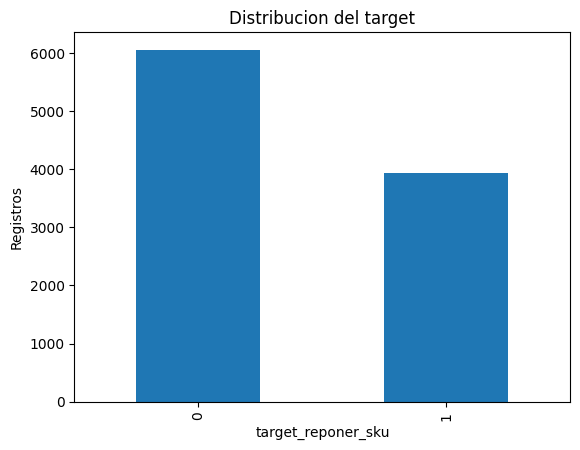

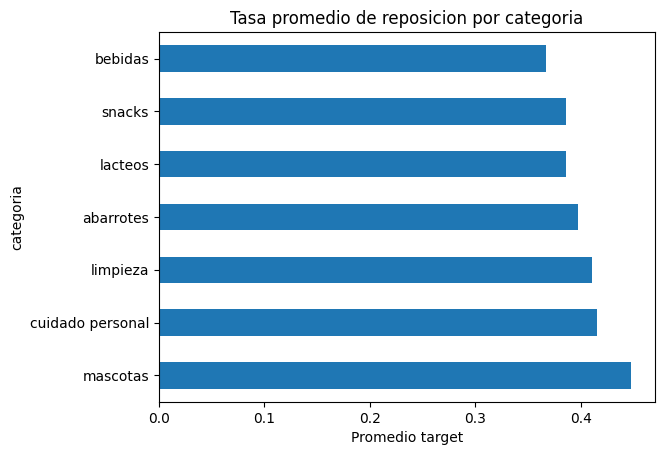

In [150]:
# Distribucion del target
dataset_nodup_imp['target_reponer_sku'].value_counts().sort_index().plot(kind='bar', title='Distribucion del target')
plt.xlabel('target_reponer_sku')
plt.ylabel('Registros')
plt.show()

# Tasa de target por categoria
(dataset_nodup_imp.groupby('categoria')['target_reponer_sku']
   .mean()
   .sort_values(ascending=False)
   .plot(kind='barh', title='Tasa promedio de reposicion por categoria'))
plt.xlabel('Promedio target')
plt.show()


In [151]:
# TODO: crea 3 graficos adicionales.
# Sugerencias:
# 1. Boxplot de stock_actual por target.
# 2. Boxplot de forecast_7d por target.
# 3. Tasa de target por promo_activa.
# 4. Tasa de target por prioridad_comercial.
# 5. Scatter stock_actual vs forecast_7d coloreado por target.

# Escribe tu codigo debajo:

Text(0, 0.5, 'Stock actual')

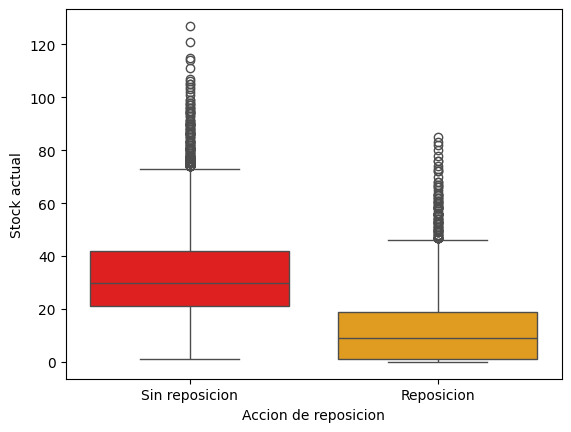

In [152]:
# 1. Boxplot de stock_actual por target.

ax = sns.boxplot(x = dataset_nodup_imp['target_reponer_sku'],
            y = dataset_nodup_imp['stock_actual'],
            palette=["red", "orange"])


ax.set_xticklabels(["Sin reposicion", "Reposicion"])
ax.set_xlabel("Accion de reposicion")
ax.set_ylabel("Stock actual")

Text(0, 0.5, 'Prediccion de Demanda (7 dias)')

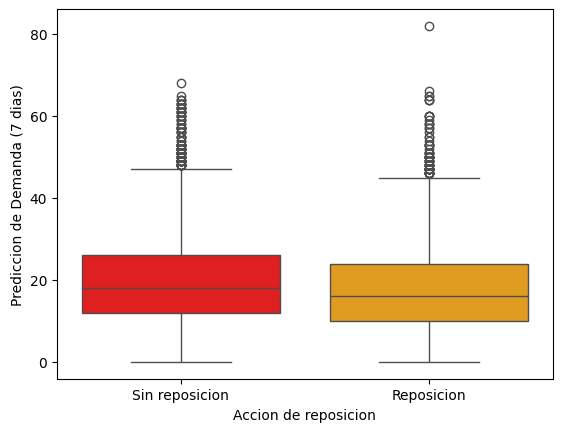

In [153]:
# 2. Boxplot de forecast_7d por target.

ax = sns.boxplot(x = dataset_nodup_imp['target_reponer_sku'],
            y = dataset_nodup_imp['forecast_7d'],
            palette=["red", "orange"])


ax.set_xticklabels(["Sin reposicion", "Reposicion"])
ax.set_xlabel("Accion de reposicion")
ax.set_ylabel("Prediccion de Demanda (7 dias)")

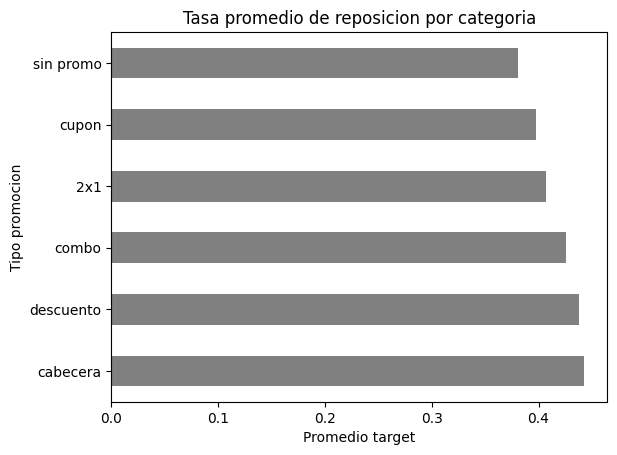

In [154]:
# 3. Tasa de target por promo_activa.

(
   dataset_nodup_imp.groupby('tipo_promo')['target_reponer_sku']
   .mean()
   .sort_values(ascending=False)
   .plot(kind='barh', title='Tasa promedio de reposicion por categoria', color='gray')
   )

plt.xlabel('Promedio target')
plt.ylabel("Tipo promocion")
plt.show()

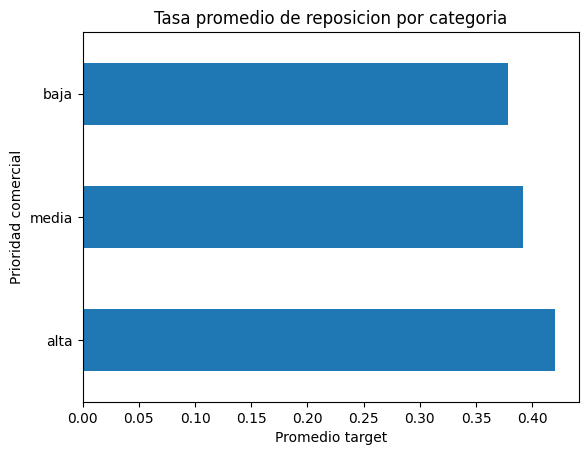

In [155]:
# 4. Por prioridad comercial


(dataset_nodup_imp.groupby('prioridad_comercial')['target_reponer_sku']
   .mean()
   .sort_values(ascending=False)
   .plot(kind='barh', title='Tasa promedio de reposicion por categoria'))

plt.xlabel('Promedio target')
plt.ylabel("Prioridad comercial")
plt.show()

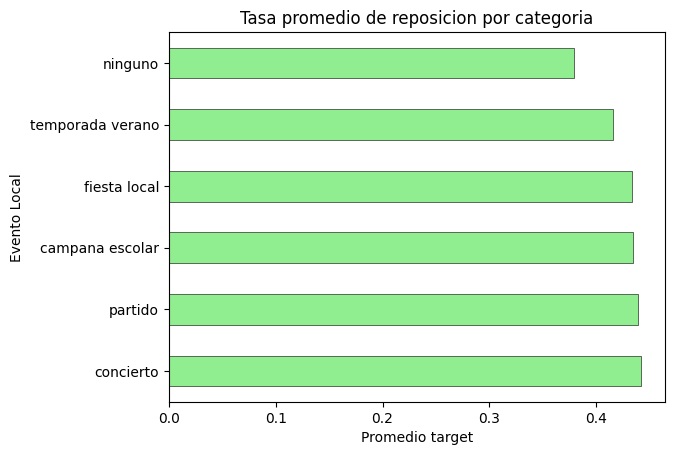

In [156]:
# 4. Por prioridad comercial


(dataset_nodup_imp.groupby('evento_local')['target_reponer_sku']
   .mean()
   .sort_values(ascending=False)
   .plot(kind='barh', title='Tasa promedio de reposicion por categoria', color='lightgreen', edgecolor = "#000000",
         width=0.5, linewidth=0.4))

plt.xlabel('Promedio target')
plt.ylabel("Evento Local")
plt.show()

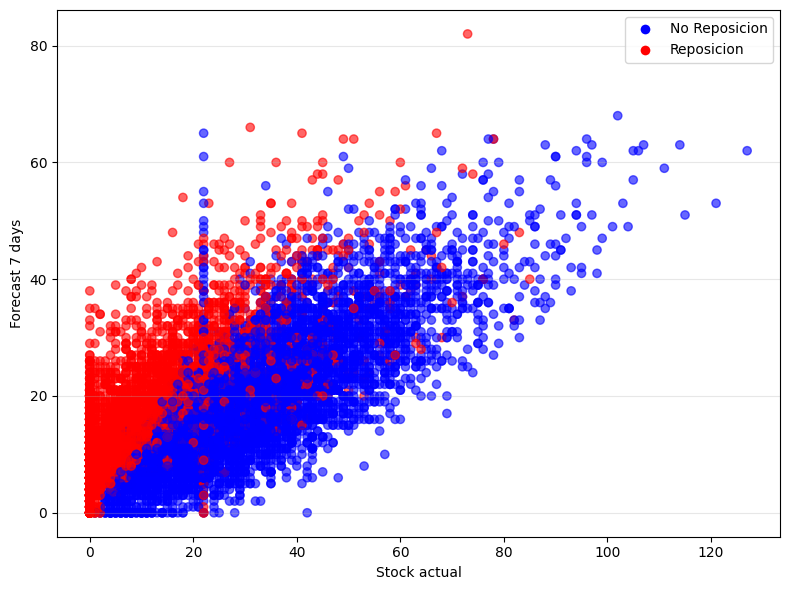

In [157]:
# 5. Scatter stock_actual vs forecast_7d coloreado por target.

plt.figure(figsize=(8,6))

plt.scatter(
    x=dataset_nodup_imp['stock_actual'],
    y=dataset_nodup_imp['forecast_7d'],
    alpha=0.6,
    marker="o",
    color=dataset_nodup_imp["target_reponer_sku"].map({0:"blue",1:"red"})
)

# Leyenda personalizada
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='No Reposicion',
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w',
           label='Reposicion',
           markerfacecolor='red', markersize=8)
]

plt.legend(handles=legend_elements, title="")

plt.xlabel("Stock actual")
plt.ylabel("Forecast 7 days")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



In [158]:
# Additional Data Cleaning 

dummys_1 = pd.get_dummies(dataset_nodup_imp["categoria"], dummy_na=False, dtype=int)
dummys_1.columns 

Index(['abarrotes', 'bebidas', 'cuidado personal', 'lacteos', 'limpieza', 'mascotas', 'snacks'], dtype='object')

In [159]:

dummys_2 = pd.get_dummies(dataset_nodup_imp["formato_tienda"], dummy_na=False, dtype=int)
dummys_2.columns 

Index(['bodega', 'cash&carry', 'ecommerce', 'hipermercado', 'minimarket', 'supermercado'], dtype='object')

In [160]:
dataset_nodup_imp['quiebres_30d'].value_counts()

quiebres_30d
4    2041
3    1998
2    1853
1    1683
0    1115
5     850
6     283
7     127
8      39
Name: count, dtype: int64

In [161]:
dataset_prod = pd.concat([ dataset_nodup_imp , dummys_1, dummys_2], axis = 1 )

## IV. Training and Tunning Machine Learning Models

In [162]:
dataset_prod

,sku_id,tienda_id,fecha,region,ciudad,distrito,formato_tienda,canal_venta,cluster_tienda,segmento_cliente_principal,categoria,subcategoria,marca,proveedor,sku_estado,precio_lista,precio_venta,costo_unitario,margen_pct,descuento_pct,stock_actual,stock_seguridad,inventario_transito,dias_inventario,ventas_unidades_7d,ventas_unidades_30d,ventas_valor_30d,unidades_devueltas_30d,rotacion_30d,forecast_7d,forecast_30d,error_forecast_pct,quiebres_7d,quiebres_30d,visitas_tienda_30d,tickets_30d,tasa_conversion_pct,share_categoria_pct,competencia_precio_prom,precio_vs_competencia_pct,elasticidad_precio,promo_activa,tipo_promo,dias_promo_mes,inversion_trade,exhibicion_secundaria,espacio_gondola_cm,puntaje_planograma,cumplimiento_sla_pct,fill_rate_pct,lead_time_dias,frecuencia_reposicion_dias,temperatura_promedio,lluvia_mm_mes,feriado_mes,evento_local,campania_marketing,canal_abastecimiento,nivel_socioeconomico_zona,distancia_cd_km,capacidad_bodega_m3,merma_pct,vencimiento_dias,vida_util_dias,reclamos_30d,rating_cliente,score_tendencia_categoria,prioridad_comercial,riesgo_quiebre_score,target_reponer_sku,school,concert,local,none,sport,summer,dmissing_precio_venta,dmissing_stock_actual,dmissing_ventas_unidades_30d,dmissing_rating_cliente,date,year,month,gap_stock_vs_forecast_7d,gap_stock_vs_forecast_30d,venta_promedio_diaria_30d,ratio_stock_seguridad,presion_demanda_7d,rentabilidad_unitaria,abarrotes,bebidas,cuidado personal,lacteos,limpieza,mascotas,snacks,bodega,cash&carry,ecommerce,hipermercado,minimarket,supermercado
0,SKU-0655,TDA-029,2025-02-17,lima,callao,sjl,supermercado,tradicional,bajo valor,mascotas,lacteos,yogurt,marca_e,proveedor_local,activo,6.72,6.72,5.85,0.13,0.00,31.0,24,14,10.4,23,89.0,598.08,1,2.87,21,82.0,0.08,0,1,1962,917,0.467,0.141,5.94,0.131,-2.29,0.0,sin promo,0,0.00,0.0,116.6,0.89,0.917,0.856,7,3,24.1,182.5,0,campana escolar,trade marketing,cd regional,d,40.9,33.5,0.023,39,45,2,3.7,0.484,alta,31.3,0,1,0,0,0,0,0,0,0,0,0,2025-02-17,2025.0,2.0,-10.0,51.0,2.966667,1.291667,21,0.87,0,0,0,1,0,0,0,0,0,0,0,0,1
1,SKU-0272,TDA-036,2025-01-25,lima,callao,industrial,bodega,tradicional,alto valor,ahorro,snacks,galletas,marca_e,proveedor_local,activo,10.54,9.49,6.07,0.36,0.10,0.0,18,2,0.0,19,74.0,702.26,2,74.00,19,75.0,0.01,1,5,1633,461,0.282,0.126,9.58,-0.009,-2.49,1.0,combo,19,3833.61,0.0,37.0,0.79,0.947,0.847,4,4,20.2,35.5,0,fiesta local,ninguna,proveedor directo,c,96.9,48.7,0.079,31,120,0,3.2,0.217,alta,93.7,1,0,0,1,0,0,0,0,0,0,0,2025-01-25,2025.0,1.0,19.0,75.0,2.466667,0.000000,20,3.42,0,0,0,0,0,0,1,1,0,0,0,0,0
2,SKU-0033,TDA-221,2025-08-31,lima,lima,surco,minimarket,moderno,medio valor,familias,bebidas,jugos,marca_e,proveedor_local,activo,6.84,6.29,4.53,0.28,0.08,27.0,14,0,15.9,14,51.0,320.79,1,1.89,18,60.0,0.18,0,4,3147,990,0.315,0.172,6.52,-0.035,-1.95,1.0,2x1,17,4059.31,0.0,35.7,0.80,0.866,0.704,2,14,30.7,36.6,0,ninguno,influencers,cd central,b,3.8,51.7,0.074,210,730,1,4.0,0.312,media,42.8,0,0,0,0,1,0,0,0,0,0,0,2025-08-31,2025.0,8.0,-9.0,33.0,1.700000,1.928571,18,1.76,0,1,0,0,0,0,0,0,0,0,0,1,0
3,SKU-0245,TDA-068,2025-02-07,lima,callao,la molina,supermercado,tradicional,alto valor,familias,bebidas,isotonicas,marca_e,proveedor_norte,temporal,5.23,5.23,4.34,0.17,0.00,8.0,13,5,3.0,19,81.0,423.63,3,10.12,15,68.0,0.16,1,5,4598,1241,0.270,0.259,6.26,-0.165,-2.20,0.0,sin promo,0,0.00,1.0,37.1,0.75,0.794,0.875,12,7,16.5,139.5,0,ninguno,ninguna,cd central,c,705.3,12.9,0.027,39,60,0,4.1,0.391,media,74.5,1,0,0,0,1,0,0,0,0,0,0,2025-02-07,2025.0,2.0,7.0,60.0,2.700000,0.615385,16,0.89,0,1,0,0,0,0,0,0,0,0,0,0,1
4,SKU-0423,TDA-007,2025-01-20,lima,callao,comas,minimarket,mayorista,descuento,jovenes,limpieza,desinfectante,marca_b,proveedor_andes,activo,39.49,28.04,19.91,0.29,0.29,28.0,4,9,27.1,7,31.0,869.24,1,1.11,5,25.0,0.19,1,5,1666,465,0.279,0.030,46.38,-0.395,-1.93,1.0,cupon,11,287.46,0.0,75.3,0.87,0.838,0.985,2,8,31.8,41.8,1,ninguno,trade marketing,cd regional,c,61.3,82.4,0.026,120,180,0,4.6,0.317,media,41.2,0,0,0,0,1,0,0,0,0,0,0,202

In [163]:
dataset_prod['feriado_mes']

0       0
1       0
2       0
3       0
4       1
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: feriado_mes, Length: 9989, dtype: int64

In [ ]:
# Features and target 

X = dataset_prod[['abarrotes', 'bebidas', 'cuidado personal', 'lacteos', 'limpieza', 'mascotas', 'snacks',
                       'bodega', 'cash&carry', 'ecommerce', 'hipermercado', 'minimarket', 'supermercado',
                       'precio_venta',
                       'stock_actual',
                       'stock_seguridad',
                       'dias_inventario',
                       'forecast_7d', 'forecast_30d',
                       'quiebres_30d', 'quiebres_7d',
                       'unidades_devueltas_30d', 'rotacion_30d',
                       'visitas_tienda_30d', 'tickets_30d',
                       'promo_activa',
                       'school', 'concert', 'local', 'sport', 'summer',
                       'temperatura_promedio']]

y = dataset_prod['target_reponer_sku']

In [165]:
object_numeric = dataset_prod.select_dtypes(include='number').columns 
object_numeric

# 'ventas_unidades_7d', 'ventas_unidades_30d'

Index(['precio_lista', 'precio_venta', 'costo_unitario', 'margen_pct', 'descuento_pct', 'stock_actual', 'stock_seguridad', 'inventario_transito',
       'dias_inventario', 'ventas_unidades_7d', 'ventas_unidades_30d', 'ventas_valor_30d', 'unidades_devueltas_30d', 'rotacion_30d', 'forecast_7d',
       'forecast_30d', 'error_forecast_pct', 'quiebres_7d', 'quiebres_30d', 'visitas_tienda_30d', 'tickets_30d', 'tasa_conversion_pct', 'share_categoria_pct',
       'competencia_precio_prom', 'precio_vs_competencia_pct', 'elasticidad_precio', 'promo_activa', 'dias_promo_mes', 'inversion_trade',
       'exhibicion_secundaria', 'espacio_gondola_cm', 'puntaje_planograma', 'cumplimiento_sla_pct', 'fill_rate_pct', 'lead_time_dias',
       'frecuencia_reposicion_dias', 'temperatura_promedio', 'lluvia_mm_mes', 'feriado_mes', 'distancia_cd_km', 'capacidad_bodega_m3', 'merma_pct',
       'vencimiento_dias', 'vida_util_dias', 'reclamos_30d', 'rating_cliente', 'score_tendencia_categoria', 'riesgo_quiebre_sc

In [166]:
X.shape

(9989, 32)

In [167]:
# Split dataset on trainning and test 


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.3,
    random_state=42,
    stratify=y 
    
)


# stratify ensures that both the training and test sets are representative
# of the original output composition 

In [168]:
# Training and Tunning the model 


numeric_columns = ['precio_venta',
                       'stock_actual',
                       'stock_seguridad',
                       'dias_inventario',
                       'forecast_7d', 'forecast_30d',
                       'quiebres_30d', 'quiebres_7d',
                       'unidades_devueltas_30d', 'rotacion_30d',
                       'visitas_tienda_30d', 'tickets_30d',
                       'temperatura_promedio']

categorical_columns = ['abarrotes', 'bebidas', 'cuidado personal', 'lacteos', 'limpieza', 'mascotas', 'snacks',
                       'bodega', 'cash&carry', 'ecommerce', 'hipermercado', 'minimarket', 'supermercado',
                       'promo_activa','school', 'concert', 'local', 'sport', 'summer']



In [169]:
def evaluate_model(name, model, X_test, y_test, threshold=0.5):
    # Evaluating model
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        'modelo': name,
        'threshold': threshold,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, proba),
        'pr_auc': average_precision_score(y_test, proba)
    }


In [ ]:
# Preprocessing Variables

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor1 = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_columns),
    ('cat', categorical_transformer, categorical_columns)
])

numeric_transformer2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor2 = ColumnTransformer(transformers=[
    ('num', numeric_transformer2, numeric_columns),
    ('cat', categorical_transformer, categorical_columns)
])


In [ ]:
# -----------------------------
# 4. Logistic Regression 
# -----------------------------

# l1: lasso and l2: ridge 

logit = Pipeline([
    ("preprocessor", preprocessor1),
    ("model", LogisticRegression(max_iter=3000, 
                                 random_state=42,
                                 class_weight='balanced'))
])


logit_grid = [
    {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.001, 0.01, 0.1, 1]
        },
    {
        "model__solver": ["saga"],
        "model__penalty": ["elasticnet"],
        "model__C": [0.001, 0.01, 0.1, 1],
        "model__l1_ratio": [0.1, 0.5, 0.9]
    }
]


# -----------------------------
# 5. Decision Tree 
# -----------------------------

decision_tree = Pipeline([
    ("preprocessor", preprocessor2),
    ("model", DecisionTreeClassifier(random_state=42))
])

#['ccp_alpha', 'class_weight', 'criterion', 'max_depth', 'max_features', 'max_leaf_nodes', 'min_impurity_decrease', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'monotonic_cst', 'random_state', 'splitter']

decision_tree_grid = {
    "model__max_depth": [5,10, None],
    "model__min_samples_split": [50,100,150],
    "model__min_samples_leaf": [10,50,100],
    "model__class_weight": [None, "ballanced"]
}

# -----------------------------
# 5. Random Forest
# -----------------------------

random_forest = Pipeline([
    ("preprocessor", preprocessor2),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

random_forest_grid = {
    "model__n_estimators" : [200,300],
    "model__max_depth": [5,10, None],
    "model__max_features": ["sqrt",0.25],
    "model__min_samples_split": [50,100,150],
    "model__min_samples_leaf": [10,50,100],
    "model__class_weight": [None, "balanced"]
}

# -----------------------------
# 6. Gradient Boosting
# -----------------------------


gradient_boosting = Pipeline([
    ("preprocessor", preprocessor2),
    ("model", GradientBoostingClassifier(random_state=42))
])


gradient_boosting_grid = {
    "model__n_estimators": [100, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 5],
    "model__subsample": [0.8, 1.0]
}


# -----------------------------
# 6. XGboost
# -----------------------------

xgboost = Pipeline([
    ("preprocessor", preprocessor2),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1
    ))
])

xgboost_grid = {
    "model__n_estimators": [200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [5, 7,10],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1],
    "model__gamma": [0, 0.5, 1]
}



In [179]:
# -----------------------------
# 7. Cross-validation
# -----------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring={
    "roc_auc": "roc_auc",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall"
}

    

In [180]:
# -----------------------------
# 8. GridSsearch - Cross Validation
# -----------------------------

models = {
    "logistic_regression": (logit,
                            logit_grid),
    "decision_tree": ( decision_tree ,
                      decision_tree_grid),
    "random_forest": (random_forest,
                      random_forest_grid),
    "gradient_boosting": ( gradient_boosting,
                          gradient_boosting_grid),
    "xgboost": ( xgboost,
                xgboost_grid) 
}


In [181]:
# -----------------------------
# 6. Best model
# -----------------------------

# grid = GridSearchCV(
#     estimator=pipe,
#     param_grid=param_grid,
#     cv=cv,
#     scoring="roc_auc",
#     return_train_score=True,
#     n_jobs=-1,
#     verbose=3
# )


# grid = GridSearchCV(
#     estimator=pipe,
#     param_grid=param_grid,
#     cv=cv,
#     scoring={
#         "roc_auc": "roc_auc",
#         "f1": "f1",
#         "precision": "precision",
#         "recall": "recall"
#     },
#     refit="roc_auc",
#     return_train_score=True,
#     n_jobs=-1,
#     verbose=3
# )

In [ ]:
best_models = {}

for name, (model, param_grid) in models.items():
    
    print(f"Tunning training Model {name}")
    
    grid = GridSearchCV(
        estimator = model,
        param_grid=param_grid,
        cv = cv,
        scoring = scoring,
        refit = "f1",
        return_train_score=True,
        n_jobs = -1,
        verbose = 2
    )
    
    grid.fit(X_train, y_train)
    
    best_models[name] = grid.best_estimator_
    
    print(f"Best F1-score for {name}: {grid.best_score_:.4f}")
    print(f"Optimal parameters: {grid.best_estimator_}")

Model training logistic_regression
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best ROC-AUC for logistic_regression: 0.9563
Optimal parameters: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['precio_venta',
                                                   'stock_actual',
                                                   'stock_seguridad',
                                                   'dias_inventario',
                                                   'forecast_7d',
                                                   'forecast_30

In [183]:
best_models.keys()

dict_keys(['logistic_regression', 'decision_tree', 'random_forest', 'gradient_boosting', 'xgboost'])

In [184]:
best_models

{'logistic_regression': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['precio_venta',
                                                    'stock_actual',
                                                    'stock_seguridad',
                                                    'dias_inventario',
                                                    'forecast_7d',
                                                    'forecast_30d',
                                                    'quiebres_30d',
                                                    'qu

In [185]:
# Logistic Regression #

model = best_models['logistic_regression']

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print('logistic regression')
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

# Decision Tree #

model = best_models['decision_tree']

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Decision Tree")
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

logistic regression
Test ROC-AUC: 0.9608233521207667
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      1816
           1       0.86      0.89      0.87      1181

    accuracy                           0.90      2997
   macro avg       0.89      0.90      0.90      2997
weighted avg       0.90      0.90      0.90      2997

Decision Tree
Test ROC-AUC: 0.9561774722384898
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      1816
           1       0.92      0.85      0.88      1181

    accuracy                           0.91      2997
   macro avg       0.91      0.90      0.91      2997
weighted avg       0.91      0.91      0.91      2997



In [186]:

# Random Forest # 

model = best_models['random_forest']

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Random Forest")
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

Random Forest
Test ROC-AUC: 0.9646914994013137
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      1816
           1       0.94      0.83      0.88      1181

    accuracy                           0.91      2997
   macro avg       0.92      0.90      0.91      2997
weighted avg       0.92      0.91      0.91      2997



In [187]:
# Gradient Boosting # 

model = best_models['gradient_boosting']

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Gradient Boosting")
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

# XGBoost #

model = best_models['xgboost']

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("XGBoost")
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))


Gradient Boosting
Test ROC-AUC: 0.9747143651128178
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      1816
           1       0.95      0.88      0.91      1181

    accuracy                           0.93      2997
   macro avg       0.94      0.92      0.93      2997
weighted avg       0.93      0.93      0.93      2997

XGBoost
Test ROC-AUC: 0.9754944290472869
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      1816
           1       0.96      0.88      0.92      1181

    accuracy                           0.94      2997
   macro avg       0.94      0.93      0.93      2997
weighted avg       0.94      0.94      0.94      2997



## Interpretation 

- XGboost delivers the highest f1-score, ROC-AUC and accuracy 
- Gradient Boosting is the second best model

In [199]:
# Selected Model - XGBoost #

model = best_models['xgboost']

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

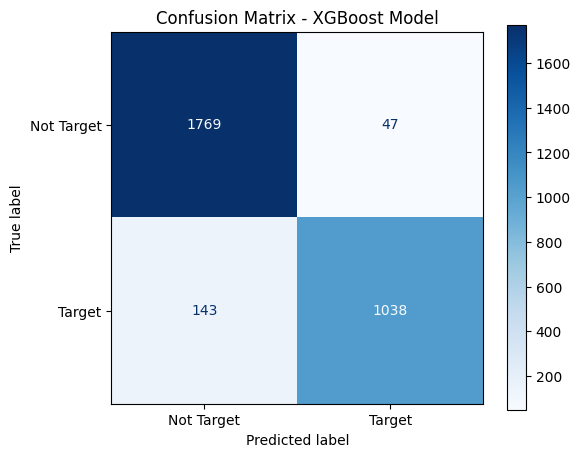

In [201]:
## Confusion Matrix for XGboost


cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Target", "Target"]
)

disp.plot(
    cmap="Blues",
    colorbar=True,
    ax=ax
)

plt.title("Confusion Matrix - XGBoost Model")
plt.show()

## Ensemble Models

- **VotingClassifier:** combina votos o probabilidades.
- **StackingClassifier:** usa modelos base y un meta-modelo que aprende a combinarlos.

In [209]:
# Voting Classifier 

voting_model = VotingClassifier(
    estimators=[
        ("logit", best_models["logistic_regression"]),
        ("rf", best_models["random_forest"]),
        ("gb", best_models["gradient_boosting"]),
        ("xgb", best_models["xgboost"])
    ],
    voting="soft",
    n_jobs=-1
)

voting_model.fit(X_train, y_train)


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('logit', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",-1
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Us

In [210]:
# Evaluating Performace Voting Ensemble Model

ensemble_results = [evaluate_model('Voting Ensemble', voting_model, X_test, y_test)]
pd.DataFrame(ensemble_results)

,modelo,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Voting Ensemble,0.5,0.92993,0.941765,0.876376,0.907895,0.972957,0.969199


In [211]:
y_pred_voting = voting_model.predict(X_test)
y_proba_voting = voting_model.predict_proba(X_test)[:,1]

print("Voting ROC-AUC", roc_auc_score(y_test, y_proba_voting ))

print(classification_report(y_test,y_pred_voting))

Voting ROC-AUC 0.9729565402276126
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1816
           1       0.94      0.88      0.91      1181

    accuracy                           0.93      2997
   macro avg       0.93      0.92      0.93      2997
weighted avg       0.93      0.93      0.93      2997



In [212]:
## Stacking Classifier 

stacking_model = StackingClassifier(
    estimators=[
        ("dt", best_models["decision_tree"]),
        ("rf", best_models["random_forest"]),
        ("gb", best_models["gradient_boosting"]),
        ("xgb", best_models["xgboost"])
    ],
    final_estimator=LogisticRegression(max_iter=3000, random_state=42),
    stack_method="predict_proba",
    cv=cv,
    n_jobs=-1
)

stacking_model.fit(X_train,
                   y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('dt', ...), ('rf', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",StratifiedKFo... shuffle=True)
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'predict_proba'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while string

In [213]:
y_pred_voting = stacking_model.predict(X_test)
y_proba_voting = stacking_model.predict_proba(X_test)[:,1]

print("Voting ROC-AUC", roc_auc_score(y_test, y_proba_voting ))
print(classification_report(y_test,y_pred_voting))

Voting ROC-AUC 0.9755867498237512
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      1816
           1       0.94      0.88      0.91      1181

    accuracy                           0.93      2997
   macro avg       0.93      0.92      0.93      2997
weighted avg       0.93      0.93      0.93      2997



In [ ]:
# Evaluating Performace Stacking Ensemble Model

ensemble_results = [evaluate_model('Stacking Ensemble', stacking_model, X_test, y_test)]
pd.DataFrame(ensemble_results)

,modelo,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Voting Ensemble,0.5,0.932599,0.94379,0.881456,0.911559,0.975587,0.971794


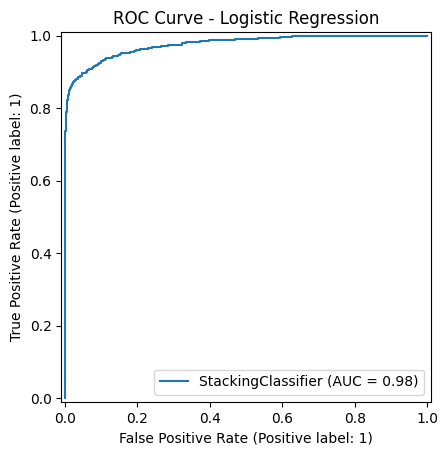

In [ ]:
# ROC curve 

RocCurveDisplay.from_estimator(
    stacking_model,
    X_test,
    y_test
)

plt.title("ROC Curve - Stacking Ensemble Model")
plt.show()

## Choosing Threshold 

In [217]:
# best_model_name = 'logistic_regression'
# best_model = best_models[best_model_name]

proba_test = stacking_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.05)
threshold_results = []

for th in thresholds:
    pred = (proba_test >= th).astype(int)
    threshold_results.append({
        'threshold': round(th, 2),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
       'ROC AUC': roc_auc_score(y_test, proba_test),
        'recomendaciones_pct': pred.mean()
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.sort_values('f1', ascending=False)

,threshold,precision,recall,f1,ROC AUC,recomendaciones_pct
10,0.60,0.955638,0.875529,0.913831,0.975587,0.361028
11,0.65,0.964252,0.867909,0.913547,0.975587,0.354688
9,0.55,0.948858,0.879763,0.913005,0.975587,0.365365
12,0.70,0.968571,0.861135,0.911699,0.975587,0.350350
8,0.50,0.943790,0.881456,0.911559,0.975587,0.368035
13,0.75,0.976744,0.853514,0.910981,0.975587,0.344344
7,0.45,0.934046,0.887384,0.910117,0.975587,0.374374
6,0.40,0.924017,0.895851,0.909716,0.975587,0.382049
14,0.80,0.978452,0.845893,0.907357,0.975587,0.340674
5,0.35,0.910653,0.897544,0.904051,0.975587,0.388388


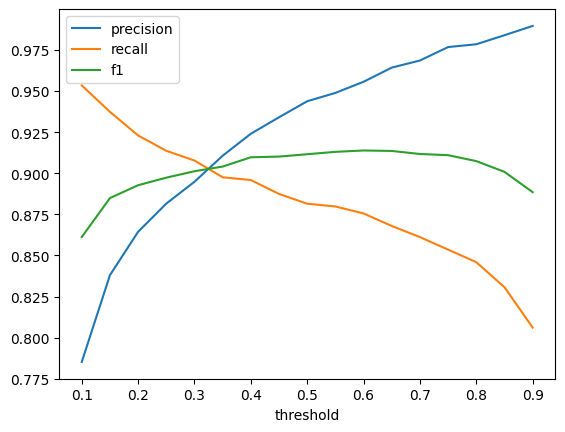

In [219]:
# The threshold that maximizes F1 is 0.6

threshold_df.plot(x='threshold', y=['precision','recall','f1'])
plt.show()

[[1768   48]
 [ 147 1034]]
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      1816
           1       0.96      0.88      0.91      1181

    accuracy                           0.93      2997
   macro avg       0.94      0.92      0.93      2997
weighted avg       0.94      0.93      0.93      2997



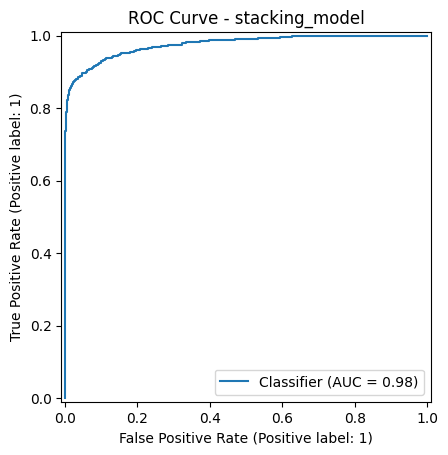

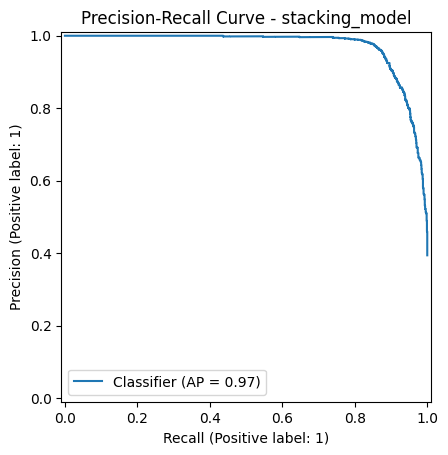

In [220]:
UMBRAL_FINAL = 0.6  # TODO: ajusta segun el trade-off precision/recall.

pred_final = (proba_test >= UMBRAL_FINAL).astype(int)
print(confusion_matrix(y_test, pred_final))
print(classification_report(y_test, pred_final))

# Curvas ROC y Precision-Recall
RocCurveDisplay.from_predictions(y_test, proba_test)
plt.title(f'ROC Curve - stacking_model')
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, proba_test)
plt.title(f'Precision-Recall Curve - stacking_model')
plt.show()


## Explicabilidad

In [ ]:
# best_model_name = 'logistic_regression'
# best_model = best_models[best_model_name]

In [221]:
sample_size = min(3000, len(X_test))
X_sample = X_test.sample(sample_size, random_state=42)
y_sample = y_test.loc[X_sample.index]

perm = permutation_importance(
    stacking_model, X_sample, y_sample,
    n_repeats=2, random_state=42, scoring='f1'
)

importance_df = pd.DataFrame({
    'feature': X_sample.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

importance_df.head(15)

,feature,importance_mean,importance_std
14,stock_actual,0.144205,0.001754
15,stock_seguridad,0.124278,0.000677
16,dias_inventario,0.115516,0.000795
22,rotacion_30d,0.069947,0.004285
20,quiebres_7d,0.003650,0.000237
18,forecast_30d,0.002825,0.000437
19,quiebres_30d,0.002510,0.002498
30,summer,0.002388,0.000239
24,tickets_30d,0.001315,0.000994
3,lacteos,0.001154,0.000278


In [ ]:
# TODO: interpreta las 5 variables mas importantes.
# Escribe en comentarios o Markdown:
# 1. La posibilidad de perdidas por falta de stock depende del nivel de stock actual
# 2. El stock de seguridad tambien determina la posibilida de reducir perdidas 
# por falta de stock
# 3. Dias en inventario es una proxy de rotación que incrementa el riesgo de sub-stock
# 4. Rotación va en la misma idea que dias de inventario
# 5. Los productos de mayir riesgo de sub-stock en 7 dias deben priorizarse.  


## 15. Prediccion para nuevos casos

Simulamos como se usaria el modelo en negocio. La salida debe incluir probabilidad, decision y accion sugerida.


In [222]:
# Tomamos algunos registros del test como si fueran nuevos casos.
nuevos_casos = X_test.head(10).copy()
probabilidades = stacking_model.predict_proba(nuevos_casos)[:, 1]
decisiones = (probabilidades >= UMBRAL_FINAL).astype(int)

salida = nuevos_casos.copy()
salida['prob_reponer'] = probabilidades.round(3)
salida['decision_reponer'] = decisiones

# Agregamos IDs desde df original usando indices si estan disponibles.
salida[['prob_reponer', 'decision_reponer']].head(10)


,prob_reponer,decision_reponer
5327,0.060,0
7515,0.055,0
5310,0.982,1
9125,0.033,0
299,0.980,1
8175,0.042,0
6679,0.209,0
7445,0.981,1
6104,0.981,1
3016,0.101,0


In [224]:
# TODO: crea una columna accion_sugerida.
# Regla ejemplo:
# - Si prob_reponer >= 0.75: 'Reposicion urgente'
# - Si prob_reponer >= 0.50: 'Reponer en siguiente ciclo'
# - Si prob_reponer < 0.50: 'Monitorear'

def accion_function(x):
    
    if x>=0.7:
        return 'Reposicion urgente'
    
    elif x>=0.6:
        return "Reponer no inmediatamente"
    
    else: 
        return  'Monitorear'

salida['accion_sugerida'] = salida['prob_reponer'].map(accion_function)
salida[['prob_reponer', 'decision_reponer', 'accion_sugerida']].head(10)


,prob_reponer,decision_reponer,accion_sugerida
5327,0.060,0,Monitorear
7515,0.055,0,Monitorear
5310,0.982,1,Reposicion urgente
9125,0.033,0,Monitorear
299,0.980,1,Reposicion urgente
8175,0.042,0,Monitorear
6679,0.209,0,Monitorear
7445,0.981,1,Reposicion urgente
6104,0.981,1,Reposicion urgente
3016,0.101,0,Monitorear



## 16. Beneficio de negocio

La ciencia de datos debe traducirse en impacto. Ejemplos de beneficios:

- Menos quiebres de stock.
- Menos ventas perdidas.
- Mejor fill rate.
- Menor sobrestock y merma.
- Mejor priorizacion del transporte y abastecimiento.

**Actividad:** crea una simulacion simple de beneficio.


In [227]:
# Simulacion simple de impacto
# Supuestos didacticos, debes ajustarlos al negocio real.
venta_promedio_por_sku = 200       # soles por oportunidad recuperada
costo_sobrestock_por_sku = 165     # soles por falso positivo

cm = confusion_matrix(y_test, pred_final)
tn, fp, fn, tp = cm.ravel()

beneficio_recuperado = tp * venta_promedio_por_sku
costo_sobrestock = fp * costo_sobrestock_por_sku
beneficio_neto = beneficio_recuperado - costo_sobrestock

print('TP:', tp, 'FP:', fp, 'FN:', fn, 'TN:', tn)
print('Beneficio recuperado estimado:', beneficio_recuperado)
print('Costo sobrestock estimado:', costo_sobrestock)
print('Beneficio neto estimado:', beneficio_neto)

# TODO: cambia los supuestos y analiza como cambia el beneficio.


TP: 1034 FP: 48 FN: 147 TN: 1768
Beneficio recuperado estimado: 206800
Costo sobrestock estimado: 7920
Beneficio neto estimado: 198880



## 17. Conclusiones del proyecto

Completa tus conclusiones:

1. Que modelo eliges y por que?
2. Que umbral recomiendas?
3. Que variables explican mejor la decision?
4. Que beneficio de negocio esperas?
5. Que datos adicionales pedirias para mejorar el modelo?
6. Que riesgos existen antes de llevarlo a produccion?


### TODO: escribe tus conclusiones finales aqui o en una celda Markdown.

- El mayor objetivo es reducir los Falso Negativos 
No reponer cuando hay quiebre en stock, lo cual genera perdidas

- Elijo el Stacking Ensemble Model pues proporciona mejores indicadores 
- Precision 0.94379, Recall	0.881456, f1-score	0.911559

- Sugiero un umbral 0.6 pues maximiza el f1-score y sin la necesidad de generar muchos 
Falsos negativos

- Las variables que explican la mejor decision son
stock, stock de seguridad, dias de inventario, rotación, prediccion en 7 dias

- Con respecto a riesgos antes de llevar a produccion es que los datos (features) 
esten correctos

In [ ]:
# -----------------------------
# 7. Best model
# -----------------------------

best_model = grid.best_estimator_ 


In [ ]:
print("Best hyperparameters:")
print(grid.best_params_)

print("Best CV score:")
print(grid.best_score_)

Best hyperparameters:
{'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV score:
0.9976447418213301


In [ ]:
print("Best hyperparameters:")
print(grid.best_params_)

print("Best CV score:")
print(grid.best_score_)

Best hyperparameters:
{'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV score:
0.9976447418213301


In [ ]:
# -----------------------------
# 8. Final evaluation on test set
# -----------------------------
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("ROC AUC:")
print(roc_auc_score(y_test, y_prob))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))


Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1700
           1       1.00      1.00      1.00      1097

    accuracy                           1.00      2797
   macro avg       1.00      1.00      1.00      2797
weighted avg       1.00      1.00      1.00      2797

ROC AUC:
1.0

Confusion matrix:
[[1700    0]
 [   4 1093]]


In [ ]:
# Dataframe with performance result for each model specification

results = pd.DataFrame(grid.cv_results_)

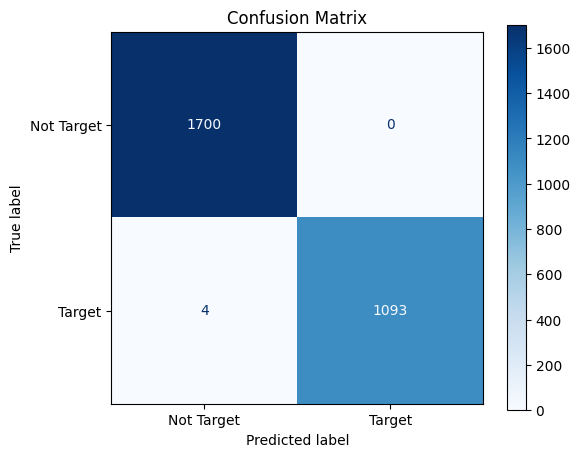

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Target", "Target"]
)

disp.plot(
    cmap="Blues",
    colorbar=True,
    ax=ax
)

plt.title("Confusion Matrix")
plt.show()

In [ ]:
summary = results[
    [
        "mean_test_roc_auc",
        "mean_test_f1",
        "mean_test_precision",
        "mean_test_recall",
        "params"
    ]
].sort_values("mean_test_f1", ascending=False)

print(summary.head(10))

    mean_test_roc_auc  mean_test_f1  mean_test_precision  mean_test_recall                                             params
4            1.000000      0.997645             1.000000          0.995307  {'model__C': 0.1, 'model__penalty': 'l1', 'mod...
2            1.000000      0.991301             1.000000          0.982796  {'model__C': 0.01, 'model__penalty': 'l1', 'mo...
14           0.999997      0.989099             1.000000          0.978493  {'model__C': 0.1, 'model__l1_ratio': 0.9, 'mod...
0            1.000000      0.983674             0.967900          1.000000  {'model__C': 0.001, 'model__penalty': 'l1', 'm...
13           0.999840      0.979610             1.000000          0.960120  {'model__C': 0.1, 'model__l1_ratio': 0.5, 'mod...
5            0.999374      0.975550             0.998352          0.953868  {'model__C': 0.1, 'model__penalty': 'l2', 'mod...
12           0.999492      0.975541             0.998761          0.953477  {'model__C': 0.1, 'model__l1_ratio': 0.1, 

In [ ]:
best_idx = grid.best_index_

print("ROC-AUC   :", results.loc[best_idx, "mean_test_roc_auc"])
print("F1        :", results.loc[best_idx, "mean_test_f1"])
print("Precision :", results.loc[best_idx, "mean_test_precision"])
print("Recall    :", results.loc[best_idx, "mean_test_recall"])

ROC-AUC   : 1.0
F1        : 0.9976447418213301
Precision : 1.0
Recall    : 0.9953071489726029
